<a href="https://colab.research.google.com/github/MatiasO2312/Aprendizaje-Automatico/blob/main/Clase%205/%20Clase%205%20AA%20Matias%20Oroz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importar y cargar datos**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Cargar dataset Titanic desde URL pública
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print(df.head())
print("\nValores nulos:\n", df.isnull().sum())

Shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

# **Preprocesamiento**

In [2]:
# Seleccionar columnas relevantes
df = df[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]].dropna()

# Codificar variable categórica
df["Sex"] = LabelEncoder().fit_transform(df["Sex"])  # female=0, male=1

X = df.drop("Survived", axis=1)
y = df["Survived"]

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar (necesario para KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (571, 6) | Test: (143, 6)


# **Modelo KNN**

=== KNN ===
Accuracy: 0.7622377622377622
               precision    recall  f1-score   support

No sobrevivió       0.82      0.78      0.80        87
   Sobrevivió       0.68      0.73      0.71        56

     accuracy                           0.76       143
    macro avg       0.75      0.76      0.75       143
 weighted avg       0.77      0.76      0.76       143



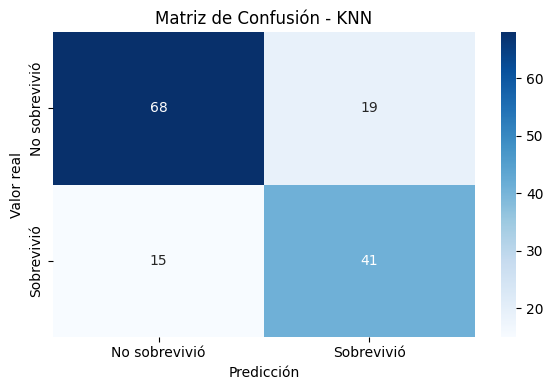

In [3]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("=== KNN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn,
      target_names=["No sobrevivió", "Sobrevivió"], zero_division=0))

# Matriz de confusión KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No sobrevivió", "Sobrevivió"],
            yticklabels=["No sobrevivió", "Sobrevivió"])
plt.title("Matriz de Confusión - KNN")
plt.ylabel("Valor real")
plt.xlabel("Predicción")
plt.tight_layout()
plt.show()

# **Mejor K para KNN**

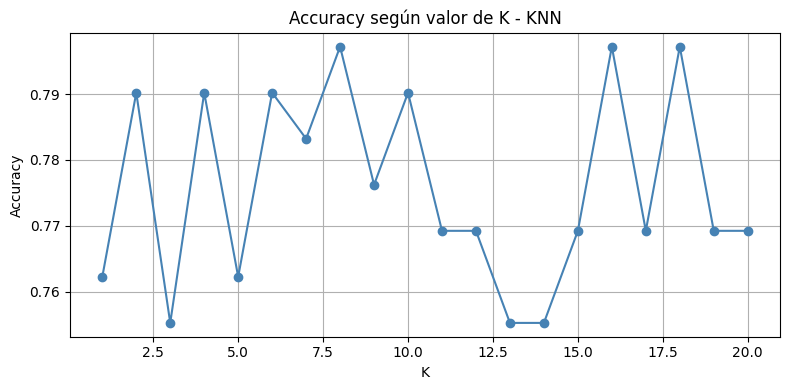

In [4]:
accuracies = []
k_values = range(1, 21)
for k in k_values:
    modelo_k = KNeighborsClassifier(n_neighbors=k)
    modelo_k.fit(X_train_scaled, y_train)
    accuracies.append(accuracy_score(y_test, modelo_k.predict(X_test_scaled)))

plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracies, marker="o", color="steelblue")
plt.title("Accuracy según valor de K - KNN")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

# **Modelo Árbol de Decisión**

=== ÁRBOL DE DECISIÓN ===
Accuracy: 0.7552447552447552
               precision    recall  f1-score   support

No sobrevivió       0.80      0.79      0.80        87
   Sobrevivió       0.68      0.70      0.69        56

     accuracy                           0.76       143
    macro avg       0.74      0.74      0.74       143
 weighted avg       0.76      0.76      0.76       143



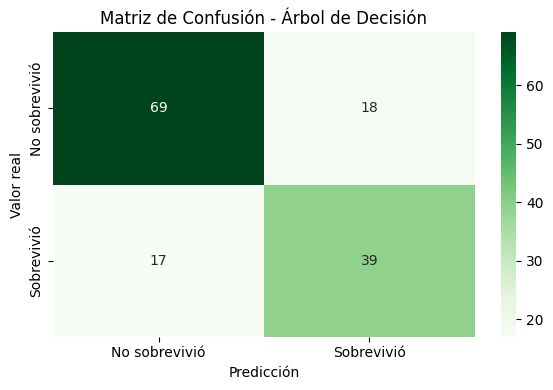

In [5]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("=== ÁRBOL DE DECISIÓN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree,
      target_names=["No sobrevivió", "Sobrevivió"], zero_division=0))

# Matriz de confusión Árbol
cm_tree = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No sobrevivió", "Sobrevivió"],
            yticklabels=["No sobrevivió", "Sobrevivió"])
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.ylabel("Valor real")
plt.xlabel("Predicción")
plt.tight_layout()
plt.show()

# **Visualización del árbol**

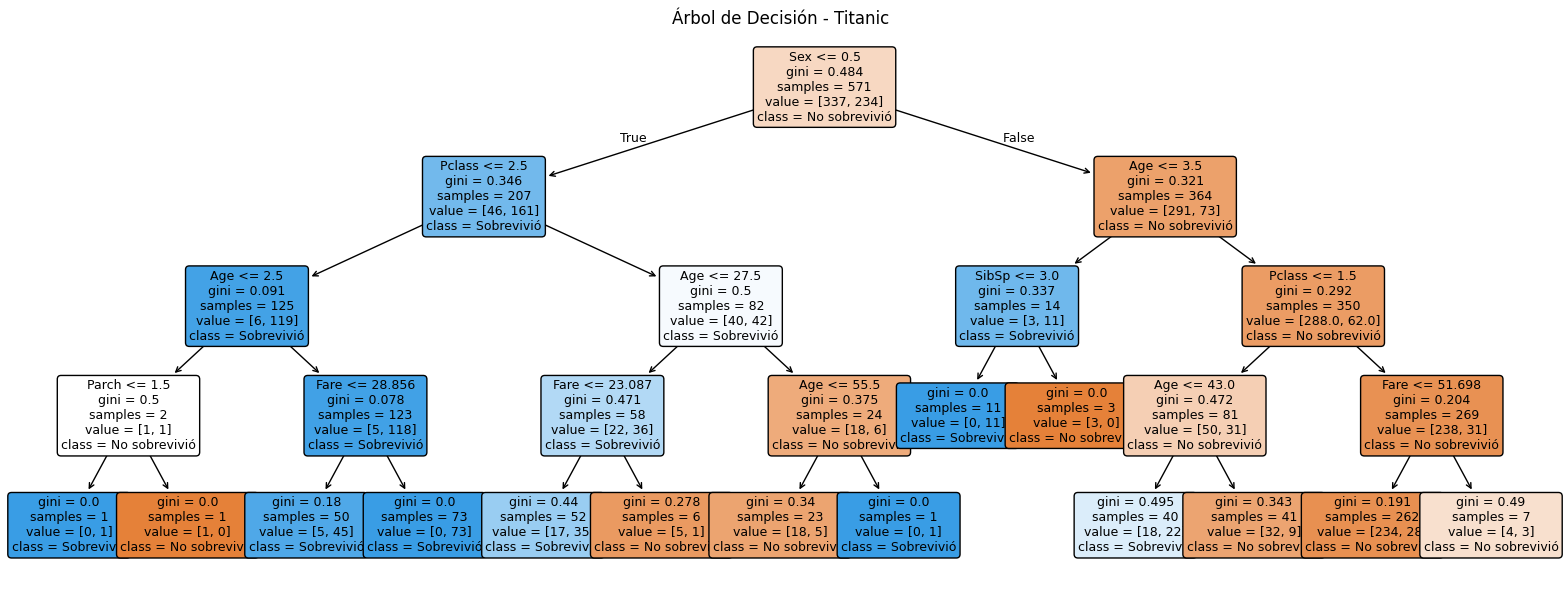

In [6]:
plt.figure(figsize=(16, 6))
plot_tree(tree, feature_names=X.columns.tolist(),
          class_names=["No sobrevivió", "Sobrevivió"],
          filled=True, rounded=True, fontsize=9)
plt.title("Árbol de Decisión - Titanic")
plt.tight_layout()
plt.show()

# **Comparación final**

In [7]:
print("=== COMPARACIÓN FINAL ===")
print(f"Accuracy KNN:              {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Accuracy Árbol de Decisión:{accuracy_score(y_test, y_pred_tree):.4f}")

=== COMPARACIÓN FINAL ===
Accuracy KNN:              0.7622
Accuracy Árbol de Decisión:0.7552
